## Makemore part 3: Activations, Layers, BatchNorm

In [1]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
with open("../names.txt", "r") as file:
    words = file.read().splitlines()

In [3]:
len(words)

32033

## Kaiming initialization, BatchNorm

In [4]:
# build vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
# build the dataset
def build_dataset(words, block_size = 3):
    X, Y = [], []
    for w in words:

        context = [0] * block_size # starts with "..."
        for ch in w + ".": # word.
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # remove the leftmost character from the context and append ix

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print(X.shape, Y.shape)
    return X, Y

In [6]:
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

block_size = 3

Xtr, Ytr = build_dataset(words[:n1], block_size) # Training
Xdev, Ydev = build_dataset(words[n1:n2], block_size) # Validation
Xte, Yte = build_dataset(words[n2:], block_size) # Testing

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
vocab_size = 27
embedding_size = 16
hidden_size = 512

Check [Kaiming normal initialization](https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_normal_). 

If we use `tanh` as our activation, then the parameters initialized with the normal distribution must be multiplied by the gain:
$$ \frac{5}{3} \cdot \frac{1}{\sqrt{\text{fan\_in}}} \approx 0.3  $$

In [8]:
g = torch.Generator().manual_seed(2122122121)
C = torch.randn((vocab_size, embedding_size), generator=g)
W1 = torch.randn((embedding_size * block_size, hidden_size), generator=g) * 0.2
# b1 = torch.randn(hidden_size, generator=g) * 0.01
W2 = torch.randn((hidden_size, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# Batch normalization gain and bias
bngain = torch.ones((1, hidden_size))
bnbias = torch.zeros((1, hidden_size))
bnmean_running = torch.zeros((1, hidden_size))
bnstd_running = torch.ones((1, hidden_size))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

39883


In [9]:
# A good initial loss is around
-torch.tensor(1/27).log()

tensor(3.2958)

In [10]:
loss_fn = nn.CrossEntropyLoss()
losses = []

max_steps = 200_000
batch_size = 32
for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    X, Y = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[X] # embed the characters into vectors
    hpreact = emb.view(emb.shape[0], -1) @ W1 # + b1 # train_size x hidden_size

    # Batch normalization
    bnmean_i = hpreact.mean(0, keepdim=True)
    bnstd_i = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmean_i) / (bnstd_i + 0.01) + bnbias

    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 # train_size x vocab_size
    loss = loss_fn(logits, Y)
    
    # Store statistics
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean_i
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstd_i

        losses.append(loss.log10().item())

    # Clear old gradients
    for p in parameters:
        p.grad = None
    
    # backward pass
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad # type: ignore

    if i % 10_000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")


      0/ 200000: 3.3383
  10000/ 200000: 2.3938
  20000/ 200000: 2.6480
  30000/ 200000: 2.4450
  40000/ 200000: 2.2468
  50000/ 200000: 2.3875
  60000/ 200000: 2.3889
  70000/ 200000: 1.9008
  80000/ 200000: 2.1399
  90000/ 200000: 2.3778
 100000/ 200000: 2.0320


KeyboardInterrupt: 

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50);

In [ ]:
plt.hist(h.view(-1).tolist(), 50);

In [ ]:
plt.plot(losses)

### Evaluation

In [ ]:

# Compute batch norm training stats over the full training set
with torch.no_grad():
    emb = C[Xtr]
    hpreact = emb.view(emb.shape[0], -1) @ W1 # + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

def eval_model(emb):
    hpreact = emb.view(emb.shape[0], -1) @ W1 # + b1 # hidden preactivations
    # Here we use the running stats for the training set
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # train_size x hidden_size
    logits = h @ W2 + b2 # train_size x vocab_size
    return logits

# Loss on the full set
with torch.no_grad():
    print(f"Training: {F.cross_entropy(eval_model(C[Xtr]), Ytr):.4f}")
    print(f"Validation: {F.cross_entropy(eval_model(C[Xdev]), Ydev):.4f}")


### Inference

In [ ]:

# Basic inference
with torch.no_grad():
    out = []
    context = [stoi["."]] * block_size
    while True:
        emb = C[torch.tensor(context).unsqueeze(0)]
        logits = eval_model(emb)

        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        
        pred_s = itos[int(ix)]
        if pred_s == ".":
            break

        out.append(pred_s)
        context = context[1:] + [ix]


print("".join(out))


Some alternatives to batch normalization:

- Group normalization
- Layer normalization

## Using classes

In [7]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
with open("../names.txt", "r") as file:
    words = file.read().splitlines()

In [9]:
# build the dataset
def build_dataset(words, block_size = 3):
    X, Y = [], []
    for w in words:

        context = [0] * block_size # starts with "..."
        for ch in w + ".": # word.
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # remove the leftmost character from the context and append ix

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print(X.shape, Y.shape)
    return X, Y

In [10]:
# build vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}

In [42]:
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

block_size = 3

Xtr, Ytr = build_dataset(words[:n1], block_size) # Training
Xdev, Ydev = build_dataset(words[n1:n2], block_size) # Validation
Xte, Yte = build_dataset(words[n2:], block_size) # Testing

torch.Size([182595, 3]) torch.Size([182595])
torch.Size([22747, 3]) torch.Size([22747])
torch.Size([22804, 3]) torch.Size([22804])


In [43]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True) -> None:
        self.weight = torch.randn((fan_in, fan_out)) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [44]:
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # Update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

In [45]:
class Tanh:
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [46]:
vocab_size = 27
embedding_size = 16
hidden_size = 256

In [47]:
C = torch.randn((vocab_size, embedding_size))
layers = [
    Linear(embedding_size * block_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

285643


In [58]:
max_steps = 200_000
batch_size = 32
loss_fn = nn.CrossEntropyLoss()

losses = []
ud = [] # update-to-data ratio
for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    X, Y = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[X] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = loss_fn(x, Y)

    # Backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad # type: ignore

    if i % 10_000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.detach().item():.4f}")
    
    losses.append(loss.detach().log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])


    if i >= 1000:
        break

      0/ 200000: 2.0678


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 3.76%
layer 5 (      Tanh): mean -0.00, std 0.65, saturated: 2.88%
layer 8 (      Tanh): mean -0.00, std 0.66, saturated: 1.98%
layer 11 (      Tanh): mean +0.00, std 0.67, saturated: 1.62%
layer 14 (      Tanh): mean +0.00, std 0.15, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

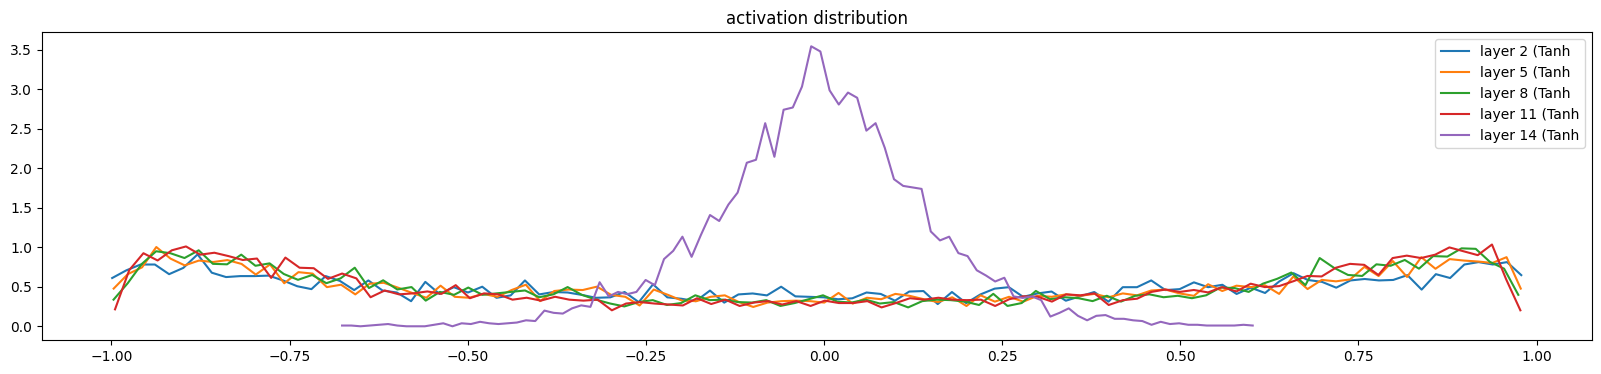

In [59]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 8.678559e-04
layer 5 (      Tanh): mean +0.000000, std 7.206365e-04
layer 8 (      Tanh): mean -0.000000, std 6.770611e-04
layer 11 (      Tanh): mean -0.000000, std 6.602522e-04
layer 14 (      Tanh): mean -0.000014, std 2.383271e-03


Text(0.5, 1.0, 'gradient distribution')

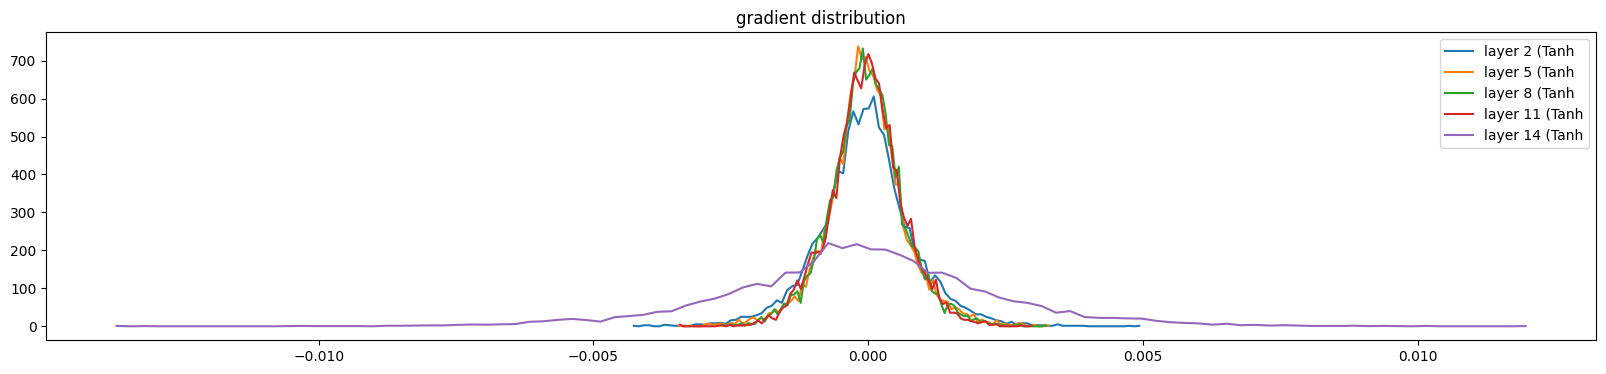

In [60]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')


weight   (27, 16) | mean +0.000000 | std 5.363614e-03 | grad:data ratio 5.117669e-03
weight  (48, 256) | mean +0.000009 | std 1.889998e-03 | grad:data ratio 7.456233e-03
weight (256, 256) | mean +0.000001 | std 9.871147e-04 | grad:data ratio 8.823899e-03
weight (256, 256) | mean -0.000004 | std 8.778102e-04 | grad:data ratio 7.959087e-03
weight (256, 256) | mean +0.000003 | std 8.180738e-04 | grad:data ratio 7.398615e-03
weight (256, 256) | mean -0.000001 | std 8.030737e-04 | grad:data ratio 7.187522e-03
weight  (256, 27) | mean +0.000000 | std 4.931362e-03 | grad:data ratio 5.646090e-02


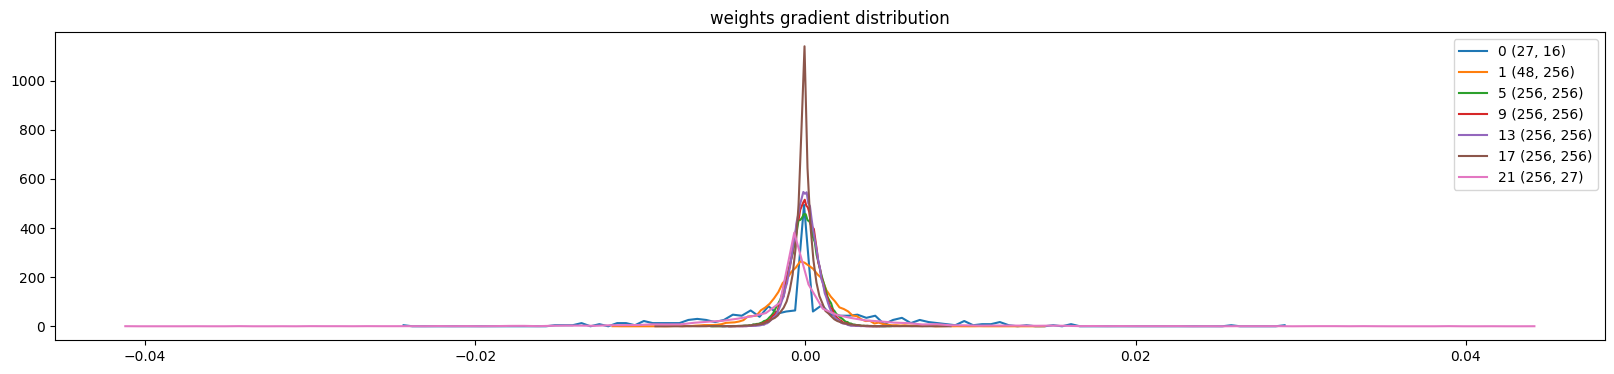

In [61]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

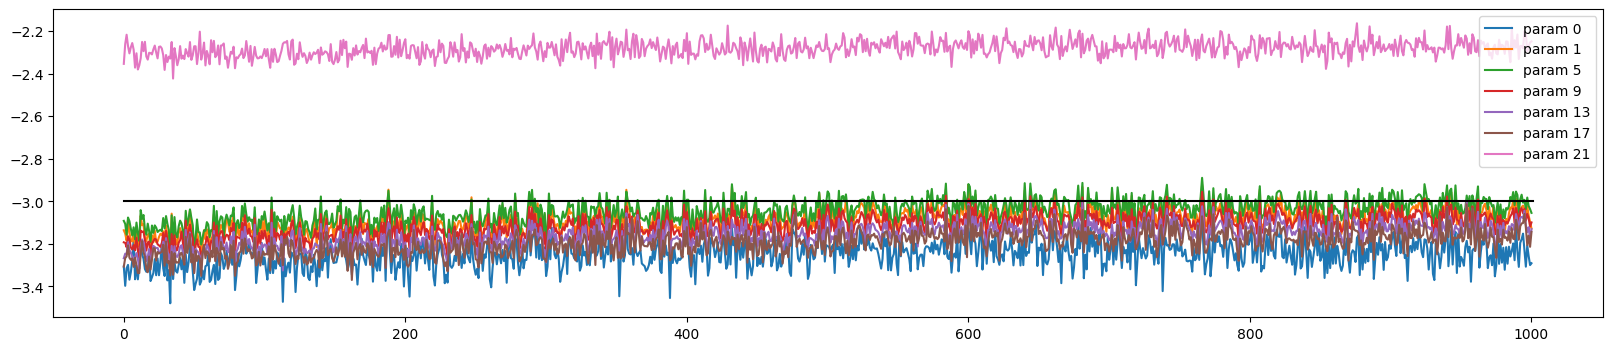

In [62]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [63]:

# Set BatchNorm layers to eval mode (use running stats, not batch stats)
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

def eval_model(emb):
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    return x

# Loss on the full set
with torch.no_grad():
    print(f"Training: {F.cross_entropy(eval_model(C[Xtr]), Ytr):.4f}")
    print(f"Validation: {F.cross_entropy(eval_model(C[Xdev]), Ydev):.4f}")

Training: 2.2746
Validation: 2.2737
